# 04 — Detailed EDA (training split only)

**Hard rule:** this notebook reads only `train.csv`; it never opens validation or test.
It examines types, memory, missingness, numerical/categorical behavior, label relations,
dates, and geography, then records feature decisions.

In [32]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "config.py").exists(): ROOT = ROOT.parent
SOURCE = ROOT / "artifacts" / "03_split" / "train.csv"
OUT = ROOT / "artifacts" / "04_eda"
CHARTS = OUT / "charts"
CHARTS.mkdir(parents=True, exist_ok=True)
assert SOURCE.exists(), "Run notebook 03 first"

train = pd.read_csv(SOURCE, low_memory=False)
date_columns = [c for c in train.columns if "date" in c or "timestamp" in c or c.endswith("_at")]
for column in date_columns:
    train[column] = pd.to_datetime(train[column], errors="coerce")
print(f"Shape: {train.shape}; memory: {train.memory_usage(deep=True).sum() / 2**20:.1f} MiB")
display(train.dtypes.rename("dtype").to_frame())

Shape: (67529, 34); memory: 50.4 MiB


,dtype
order_id,str
customer_id,str
order_status,str
order_purchase_timestamp,datetime64[us]
order_approved_at,datetime64[us]
order_delivered_carrier_date,datetime64[us]
order_delivered_customer_date,datetime64[us]
order_estimated_delivery_date,datetime64[us]
customer_unique_id,str
customer_zip_code_prefix,int64


In [69]:
missing = train.isna().sum().to_frame("missing_count")
missing["missing_share"] = missing["missing_count"] / len(train)
missing = missing.sort_values("missing_share", ascending=False)
missing.to_csv(OUT / "missing_values.csv")
display(missing.head(20))

numeric_columns = train.select_dtypes(include=np.number).columns
numerical_stats = train[numeric_columns].describe().T
numerical_stats["skew"] = train[numeric_columns].skew(numeric_only=True)
numerical_stats.to_csv(OUT / "numerical_statistics.csv")
display(numerical_stats)

categorical_columns = train.select_dtypes(include=["object", "string"]).columns
categorical_summary = pd.DataFrame({
    "cardinality": train[categorical_columns].nunique(dropna=False),
    "most_common": [train[c].mode(dropna=True).iloc[0] if not train[c].mode(dropna=True).empty else None for c in categorical_columns],
    "most_common_share": [train[c].value_counts(normalize=True, dropna=False).iloc[0] for c in categorical_columns],
}).sort_values("cardinality", ascending=False)
categorical_summary.to_csv(OUT / "categorical_summary.csv")
display(categorical_summary)

,missing_count,missing_share
primary_product_category,1223,0.018111
mean_product_photos_qty,1197,0.017726
seller_customer_distance_km,344,0.005094
customer_latitude,181,0.002680
customer_longitude,181,0.002680
mean_seller_latitude,164,0.002429
mean_seller_longitude,164,0.002429
mean_product_volume_cm3,16,0.000237
mean_product_weight_g,16,0.000237
order_approved_at,14,0.000207


,count,mean,std,min,25%,50%,75%,max,skew
customer_zip_code_prefix,67529.0,36010.051889,29908.242352,1004.000000,12061.000000,25959.000000,60360.000000,99980.000000,0.739782
customer_latitude,67348.0,-21.130754,5.705521,-33.689948,-23.588457,-22.916245,-19.996618,22.567952,1.579608
customer_longitude,67348.0,-46.177562,4.116605,-72.668881,-48.276290,-46.627122,-43.530293,-23.583939,-0.032013
item_count,67529.0,1.142072,0.541640,1.000000,1.000000,1.000000,1.000000,21.000000,8.107162
unique_product_count,67529.0,1.037702,0.222199,1.000000,1.000000,1.000000,1.000000,7.000000,7.677312
unique_seller_count,67529.0,1.012054,0.114815,1.000000,1.000000,1.000000,1.000000,5.000000,10.524938
total_item_value,67529.0,135.888797,205.194019,2.290000,45.900000,85.000000,149.900000,13440.000000,10.718895
mean_item_price,67529.0,124.239070,185.659661,1.514286,41.000000,78.970000,139.900000,6735.000000,7.802465
total_freight_value,67529.0,22.245936,20.002594,0.000000,14.100000,16.790000,23.700000,1002.290000,8.581743
mean_product_weight_g,67513.0,2171.789992,3866.698263,2.000000,300.000000,700.000000,1850.000000,40425.000000,3.579216


,cardinality,most_common,most_common_share
order_id,67529,00010242fe8c5a6d1ba2dd792cb16214,0.000015
customer_id,67529,00012a2ce6f8dcda20d059ce98491703,0.000015
customer_unique_id,65397,3e43e6105506432c953e165fb2acf44c,0.000133
customer_city,3747,sao paulo,0.146900
primary_product_category,72,bed_bath_table,0.097528
customer_state,27,SP,0.402849
primary_seller_state,22,SP,0.708481
primary_payment_type,5,credit_card,0.751203
order_status,1,delivered,1.000000


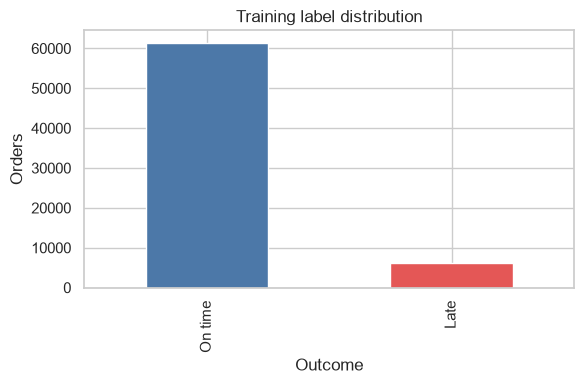

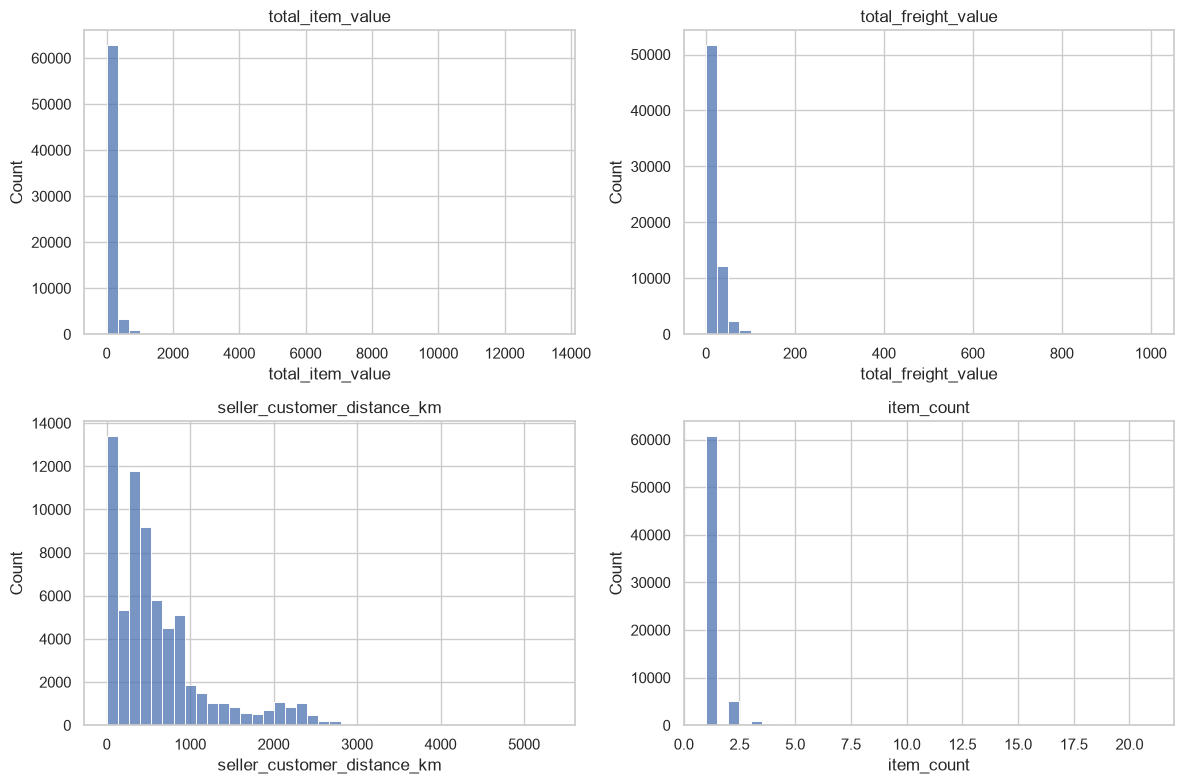

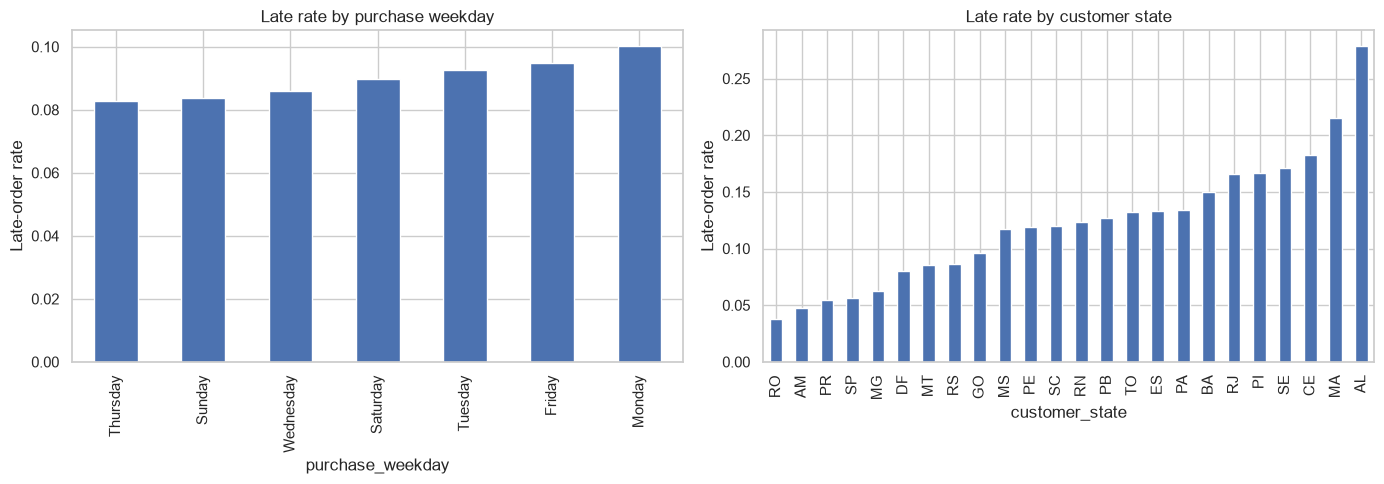

In [76]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(6, 4))
train["is_late"].map({0: "On time", 1: "Late"}).value_counts().plot.bar(ax=ax, color=["#4c78a8", "#e45756"])
ax.set(title="Training label distribution", ylabel="Orders", xlabel="Outcome")
fig.tight_layout(); fig.savefig(CHARTS / "label_distribution.png", dpi=140); plt.show()

plot_columns = ["total_item_value", "total_freight_value", "seller_customer_distance_km", "item_count"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for column, ax in zip(plot_columns, axes.flat):
    sns.histplot(train[column], bins=40, ax=ax)
    ax.set_title(column)
fig.tight_layout(); fig.savefig(CHARTS / "numeric_distributions.png", dpi=140); plt.show()

train["purchase_weekday"] = train["order_purchase_timestamp"].dt.day_name()
weekday_rate = train.groupby("purchase_weekday", observed=True)["is_late"].agg(["mean", "count"])
state_rate = train.groupby("customer_state", observed=True)["is_late"].agg(["mean", "count"]).query("count >= 100")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
weekday_rate.sort_values("mean").plot.bar(y="mean", ax=axes[0], legend=False, title="Late rate by purchase weekday")
state_rate.sort_values("mean").plot.bar(y="mean", ax=axes[1], legend=False, title="Late rate by customer state")
for ax in axes: ax.set_ylabel("Late-order rate")
fig.tight_layout(); fig.savefig(CHARTS / "late_rate_groups.png", dpi=140); plt.show()

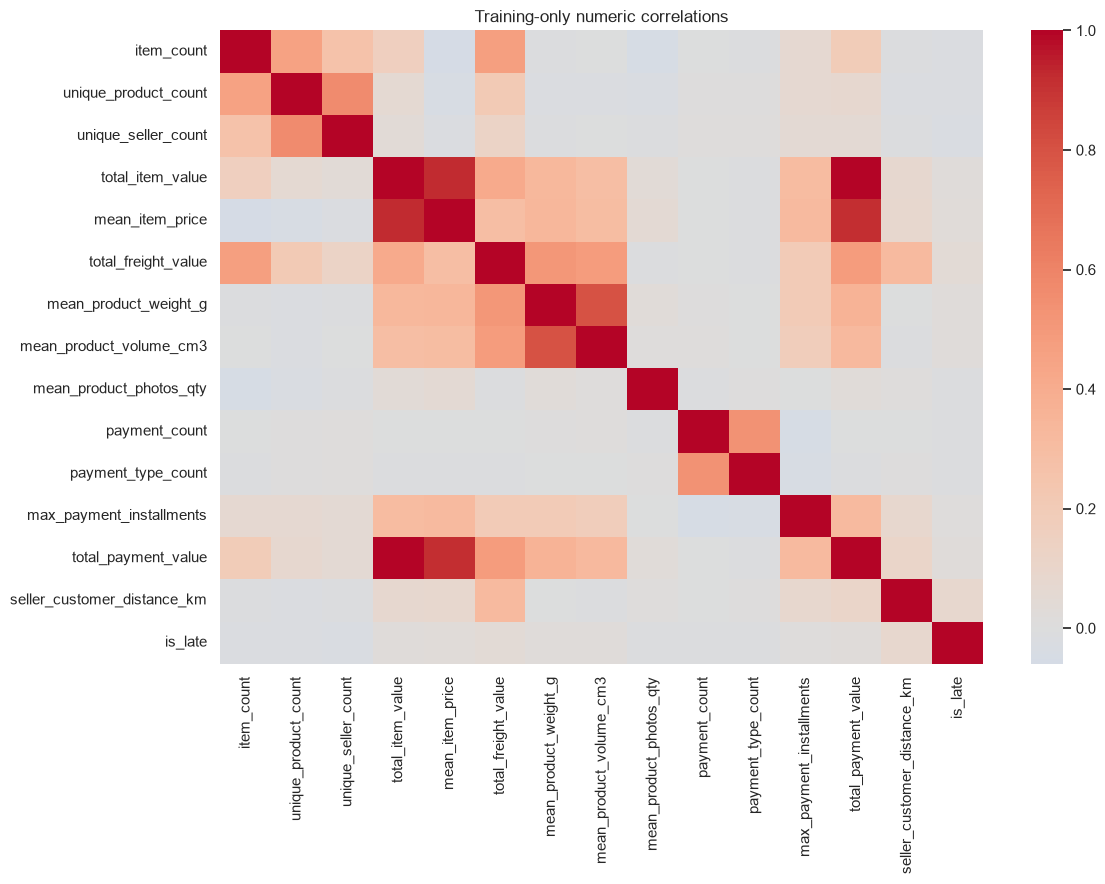

# Training EDA findings

- Training rows: **67,529**; late share: **9.03%**. This imbalance requires average precision, recall, and F1—not accuracy alone.
- Monetary, distance, weight, and volume fields are right-skewed; robust linear preprocessing and imputation are appropriate.
- Highest late-rate customer states among states with at least 100 orders: **AL, MA, CE, SE, PI**.
- IDs and free-text city names have high cardinality and will not be direct model features.
- Missing geolocation/product attributes will be median-imputed; missing categories get an explicit token.
- Date features will use purchase-time components and promised lead time. Actual delivery, carrier, approval, and review fields are excluded as future leakage.
- Candidate model: class-weighted logistic regression. It is interpretable, handles sparse one-hot features, and provides a strong first model without needless complexity.



In [77]:
safe_numeric = [
    "item_count", "unique_product_count", "unique_seller_count", "total_item_value",
    "mean_item_price", "total_freight_value", "mean_product_weight_g",
    "mean_product_volume_cm3", "mean_product_photos_qty", "payment_count",
    "payment_type_count", "max_payment_installments", "total_payment_value",
    "seller_customer_distance_km", "is_late",
]
corr = train[[c for c in safe_numeric if c in train]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Training-only numeric correlations")
fig.tight_layout(); fig.savefig(CHARTS / "correlations.png", dpi=140); plt.show()

late_share = train["is_late"].mean()
worst_states = state_rate.sort_values("mean", ascending=False).head(5).index.tolist()
findings = f'''# Training EDA findings

- Training rows: **{len(train):,}**; late share: **{late_share:.2%}**. This imbalance requires average precision, recall, and F1—not accuracy alone.
- Monetary, distance, weight, and volume fields are right-skewed; robust linear preprocessing and imputation are appropriate.
- Highest late-rate customer states among states with at least 100 orders: **{', '.join(worst_states)}**.
- IDs and free-text city names have high cardinality and will not be direct model features.
- Missing geolocation/product attributes will be median-imputed; missing categories get an explicit token.
- Date features will use purchase-time components and promised lead time. Actual delivery, carrier, approval, and review fields are excluded as future leakage.
- Candidate model: class-weighted logistic regression. It is interpretable, handles sparse one-hot features, and provides a strong first model without needless complexity.
'''
(OUT / "findings.md").write_text(findings, encoding="utf-8")
print(findings)